<a href="https://colab.research.google.com/drive/1XqNEnHcYnjZORCpTuiUFe-96xu-DiYn2?usp=sharing" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [1]:
!pip install -q langchain langchain-community langchain-chroma langchain-huggingface langchain-google-genai chromadb pymupdf ImageHash pytesseract sentence-transformers
!apt-get install -y tesseract-ocr --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.5/70.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 111.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.9/178.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9

In [1]:

import networkx as nx
from pathlib import Path

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# Knowledge Graph Builder ──────────────────────────────────────
# Imports & Setup

In [26]:
import os
import json
import pickle
import networkx as nx
from pathlib import Path

# ── Paths ──────
GRAPH_JSON_ROOT  = "/content/drive/MyDrive/ET_hackathon/processed/graph_json/"
GRAPH_OUTPUT_PATH = "/content/drive/MyDrive/ET_hackathon/processed/knowledge_graph.gpickle"
KG_PROGRESS_PATH  = "/content/drive/MyDrive/ET_hackathon/processed/kg_progress.json"

print("Imports done.")
print(f"JSON root    : {GRAPH_JSON_ROOT}")
print(f"Graph output : {GRAPH_OUTPUT_PATH}")
print(f"Progress log : {KG_PROGRESS_PATH}")

Imports done.
JSON root    : /content/drive/MyDrive/ET_hackathon/processed/graph_json/
Graph output : /content/drive/MyDrive/ET_hackathon/processed/knowledge_graph.gpickle
Progress log : /content/drive/MyDrive/ET_hackathon/processed/kg_progress.json


####  Directory Paths & JSON Discovery

In [27]:
# ── Discover all JSON files under graph_json/ subfolders ──

def get_all_json_files(json_root):
    """
    Walks all subfolders under graph_json_root.
    Returns list of dicts: { path, filename, folder_category }
    """
    json_files = []
    for folder in sorted(os.listdir(json_root)):
        folder_path = os.path.join(json_root, folder)
        if not os.path.isdir(folder_path):
            continue
        for fname in sorted(os.listdir(folder_path)):
            if fname.endswith(".json"):
                json_files.append({
                    "path": os.path.join(folder_path, fname),
                    "filename": fname,
                    "folder": folder
                })
    return json_files

json_files = get_all_json_files(GRAPH_JSON_ROOT)



In [19]:
print(f"Found {len(json_files)} JSON files:\n")
for f in json_files:
    print(f"  [{f['folder']}] {f['filename']}")

Found 36 JSON files:

  [Incident_Reports] IOCL_enquiry.json
  [Incident_Reports] Mechanical_SHAFT_SEAL_FAILURE.json
  [Incident_Reports] Mechanical_shaft_seals_for_pumps.json
  [Incident_Reports] Seal_Failure_Analysis.json
  [Incident_Reports] lbna26331enn.json
  [Incident_Reports] xvi_paper_54.json
  [Manuals] BEST_PRACTICE_MANUAL_ELECTRIC_MOTORS.json
  [Manuals] Chapter_Six_Centrifugal_Pump_Maintenance.json
  [Manuals] Compressed_Air_Manual.json
  [Manuals] Compressor_operational.json
  [Manuals] Inspection_Manual_Heat_Exchangers.json
  [Manuals] OPERATING_MANUAL_for_Centrifugal_pumps.json
  [Manuals] Unit_IV_Centrifugal_Pump.json
  [Manuals] Valve_Handbook_Philip.json
  [Manuals] apv_pumps_centrifugal_us.json
  [Manuals] ball_valves_IOM.json
  [Manuals] centrfugal_pump_maintanance.json
  [Manuals] control_valve.json
  [Manuals] pumphandbook.json
  [Procedures] A100_Metal_Pump.json
  [Procedures] BKHazarika.json
  [Procedures] Lockout_Tagout_SOP.json
  [Procedures] OSHA_safety_manag

####  JSON Loader & Validator

In [20]:


def load_json_file(path):
    """
    Loads one graph JSON file.
    Validates it has the expected keys.
    Returns parsed dict or None on failure.
    """
    try:
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)


        if "entities" not in data or "relations" not in data:
            print(f"  ✗ Missing 'entities' or 'relations' in {path}")
            return None

        if "source_pdf" not in data:
            # Fallback: infer from filename
            data["source_pdf"] = os.path.basename(path).replace(".json", ".pdf")

        return data

    except json.JSONDecodeError as e:
        print(f"  ✗ JSON parse error in {path}: {e}")
        return None
    except Exception as e:
        print(f"  ✗ Failed to load {path}: {e}")
        return None



In [28]:
# Quick test
test = load_json_file(json_files[0]["path"])
if test:
    print(f"Sample load OK: {test['source_pdf']}")
    print(f"  Entities : {len(test['entities'])}")
    print(f"  Relations: {len(test['relations'])}")

Sample load OK: IOCL_enquiry.pdf
  Entities : 34
  Relations: 35


####  Graph Persistence Functions

In [29]:
# ── Graph save / load

def load_graph():
    """Load existing graph from disk or create a fresh DiGraph."""
    if os.path.exists(GRAPH_OUTPUT_PATH):
        with open(GRAPH_OUTPUT_PATH, "rb") as f:
            G = pickle.load(f)
        print(f"Loaded existing graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    else:
        G = nx.DiGraph()
        print("No existing graph found — created fresh DiGraph.")
    return G

def save_graph(G):
    """Persist graph to Drive."""
    with open(GRAPH_OUTPUT_PATH, "wb") as f:
        pickle.dump(G, f)
    print(f"Graph saved: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# ── Progress save / load

def load_progress():
    """Load ingestion progress dict from disk."""
    if os.path.exists(KG_PROGRESS_PATH):
        with open(KG_PROGRESS_PATH, "r") as f:
            return json.load(f)
    return {}

def save_progress(progress):
    """Persist progress dict to Drive."""
    with open(KG_PROGRESS_PATH, "w") as f:
        json.dump(progress, f, indent=2)



####  Progress Tracker

In [30]:
# Initialise both
G = load_graph()
kg_progress = load_progress()

already_done = [k for k, v in kg_progress.items() if v == "done"]
print(f"\nProgress: {len(already_done)}/{len(json_files)} files already processed.")

No existing graph found — created fresh DiGraph.

Progress: 0/36 files already processed.


#### Graph Builder Functions

In [32]:
# ── Add one JSON file's entities + relations to graph

def add_json_to_graph(G, data, folder_category):
    """
    Adds entities as nodes and relations as directed edges.
    Node attributes:
        - type         (Equipment / Component / Hazard / etc.)
        - description  (from JSON if provided)
        - sources      (list of {source_pdf, folder} — appended on re-encounter)
    Edge attributes:
        - relations    (list of relation strings — multiple edges merged)
        - source_pdf
        - folder
    """
    source_pdf = data.get("source_pdf", "unknown")
    source_ref = {"source_pdf": source_pdf, "folder": folder_category}

    # ── Nodes -----------
    for entity in data.get("entities", []):
        name = str(entity.get("name", "")).strip()
        if not name:
            continue

        if G.has_node(name):
            # Node exists — append new source reference only if not already present
            existing_sources = G.nodes[name].get("sources", [])
            if source_ref not in existing_sources:
                existing_sources.append(source_ref)
            G.nodes[name]["sources"] = existing_sources
        else:
            # New node — store all attributes
            G.add_node(
                name,
                type=entity.get("type", "Unknown"),
                description=entity.get("description", ""),
                sources=[source_ref]
            )

    # ── Edges
    for rel in data.get("relations", []):
        src    = str(rel.get("source", "")).strip()
        tgt  = str(rel.get("target", "")).strip()
        relation = str(rel.get("relation", "related_to")).strip()

        if not src or not tgt:
            continue

        # Ensure both endpoint nodes exist even if missing from entities list
        for node in [src, tgt]:
            if not G.has_node(node):
                G.add_node(node,
                    type="Unknown",
                    description="",
                    sources=[source_ref]
                )

        if G.has_edge(src, tgt):
            # Edge exists — append relation label if not duplicate
            existing_rels = G[src][tgt].get("relations", [])
            if relation not in existing_rels:
                existing_rels.append(relation)
            G[src][tgt]["relations"] = existing_rels
        else:
            # New edge
            G.add_edge(src, tgt,
                relations=[relation],
                source_pdf=source_pdf,
                folder=folder_category
            )

    return G

print("Graph builder function ready.")

Graph builder function ready.


#### Main Graph Building Loop


In [33]:
# ── Main loop: JSON files → graph

def build_knowledge_graph(json_files, G, kg_progress):
    total = len(json_files)

    for idx, entry in enumerate(json_files):
        fname   = entry["filename"]
        path  = entry["path"]
        folder   = entry["folder"]

        # Skip already processed
        if kg_progress.get(fname) == "done":
            print(f"[{idx+1}/{total}] Skipping (done): {fname}")
            continue

        print(f"[{idx+1}/{total}] Processing: [{folder}] {fname}")

        data = load_json_file(path)

        if data is None:
            print(f"  ✗ Skipped due to load/validation failure.")
            kg_progress[fname] = "failed: load error"
            save_progress(kg_progress)
            continue

        nodes_before = G.number_of_nodes()
        edges_before = G.number_of_edges()

        G = add_json_to_graph(G, data, folder)

        new_nodes = G.number_of_nodes() - nodes_before
        new_edges = G.number_of_edges() - edges_before

        print(f"  ✓ +{new_nodes} nodes, +{new_edges} edges "
              f"(total: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges)")

        # Save after every file — safe to interrupt anytime
        save_graph(G)
        kg_progress[fname] = "done"
        save_progress(kg_progress)

    print(f"\n{'='*60}")
    print(f"Build complete.")
    print(f"  Final nodes : {G.number_of_nodes()}")
    print(f"  Final edges : {G.number_of_edges()}")
    print(f"  Files done  : {sum(1 for v in kg_progress.values() if v == 'done')}/{total}")
    print(f"{'='*60}")
    return G


In [34]:
## Run knowledge graph
G = build_knowledge_graph(json_files, G, kg_progress)

[1/36] Processing: [Incident_Reports] IOCL_enquiry.json
  ✓ +34 nodes, +35 edges (total: 34 nodes, 35 edges)
Graph saved: 34 nodes, 35 edges
[2/36] Processing: [Incident_Reports] Mechanical_SHAFT_SEAL_FAILURE.json
  ✓ +49 nodes, +37 edges (total: 83 nodes, 72 edges)
Graph saved: 83 nodes, 72 edges
[3/36] Processing: [Incident_Reports] Mechanical_shaft_seals_for_pumps.json
  ✓ +34 nodes, +32 edges (total: 117 nodes, 104 edges)
Graph saved: 117 nodes, 104 edges
[4/36] Processing: [Incident_Reports] Seal_Failure_Analysis.json
  ✓ +24 nodes, +32 edges (total: 141 nodes, 136 edges)
Graph saved: 141 nodes, 136 edges
[5/36] Processing: [Incident_Reports] lbna26331enn.json
  ✓ +51 nodes, +44 edges (total: 192 nodes, 180 edges)
Graph saved: 192 nodes, 180 edges
[6/36] Processing: [Incident_Reports] xvi_paper_54.json
  ✓ +29 nodes, +32 edges (total: 221 nodes, 212 edges)
Graph saved: 221 nodes, 212 edges
[7/36] Processing: [Manuals] BEST_PRACTICE_MANUAL_ELECTRIC_MOTORS.json
  ✓ +32 nodes, +13 ed

####  Graph Stats & Inspection

In [36]:
# ── Inspect the built graph

print(f"Nodes : {G.number_of_nodes()}")
print(f"Edges : {G.number_of_edges()}")

# Top 15 most connected nodes
print("\nTop 15 most connected entities (by degree):") # these are "hub" entities
degree_sorted = sorted(G.degree, key=lambda x: x[1], reverse=True)[:15]
for node, deg in degree_sorted:
    node_sources = G.nodes[node].get("sources", [])
    print(f"  {deg:3d} connections │ {node:35s} │ {len(node_sources)} source(s)")

print("\nSample relationships (first 10 edges):")
for src, tgt, data in list(G.edges(data=True))[:10]:
    relations = data.get("relations", ["?"])
    print(f"  {src:25s} ──[{relations[0]}]──▶ {tgt}")

Nodes : 906
Edges : 765

Top 15 most connected entities (by degree):
   27 connections │ A100 Pump                           │ 1 source(s)
   26 connections │ Covered process                     │ 2 source(s)
   24 connections │ Centrifugal Pump                    │ 7 source(s)
   15 connections │ Process safety management standard  │ 1 source(s)
   13 connections │ Mechanical shaft seal               │ 2 source(s)
   13 connections │ Factory premises                    │ 2 source(s)
   12 connections │ Mechanical Integrity program        │ 1 source(s)
   12 connections │ Factory                             │ 2 source(s)
   11 connections │ Pump                                │ 3 source(s)
   11 connections │ Factories Act 1948                  │ 2 source(s)
   10 connections │ Seal failure                        │ 2 source(s)
   10 connections │ Electric Motor                      │ 4 source(s)
    9 connections │ Cavitation                          │ 8 source(s)
    9 connections │ I

#### Subgraph Visualization


Visualizing subgraph centered on: 'A100 Pump'
Subgraph: 28 nodes, 28 edges


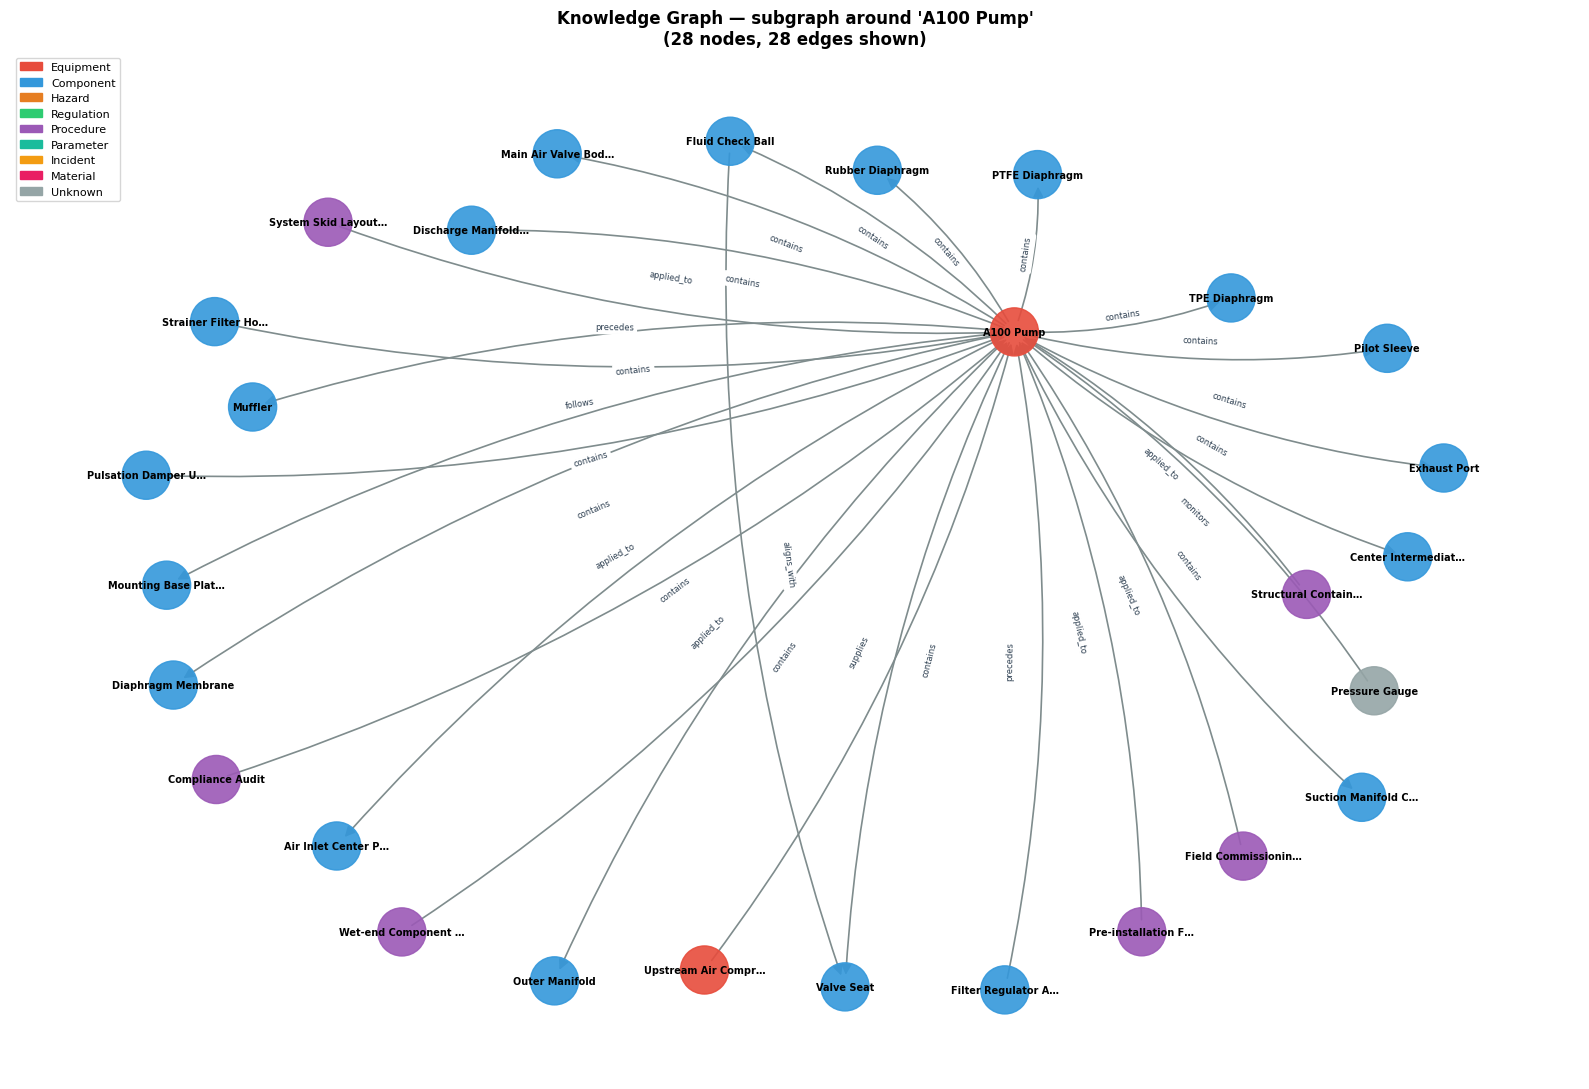

In [37]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def visualize_subgraph(G, center_node=None, n_hops=1, max_nodes=25):
    if G.number_of_nodes() == 0:
        print("Graph is empty.")
        return

    if center_node is None:
        center_node = max(G.degree, key=lambda x: x[1])[0]

    print(f"Visualizing subgraph centered on: '{center_node}'")

    nodes_to_include = {center_node}
    frontier = {center_node}
    for _ in range(n_hops):
        next_frontier = set()
        for node in frontier:
            next_frontier.update(G.predecessors(node))
            next_frontier.update(G.successors(node))
        nodes_to_include.update(next_frontier)
        frontier = next_frontier
        if len(nodes_to_include) >= max_nodes:
            break

    nodes_to_include = list(nodes_to_include)[:max_nodes]
    subG = G.subgraph(nodes_to_include).copy()
    print(f"Subgraph: {subG.number_of_nodes()} nodes, {subG.number_of_edges()} edges")

    TYPE_COLORS = {
        "Equipment"  : "#e74c3c",
        "Component"  : "#3498db",
        "Hazard"     : "#e67e22",
        "Regulation" : "#2ecc71",
        "Procedure"  : "#9b59b6",
        "Parameter"  : "#1abc9c",
        "Incident"   : "#f39c12",
        "Material"   : "#e91e63",
        "Unknown"    : "#95a5a6",
    }

    colors = [
        TYPE_COLORS.get(G.nodes[n].get("type", "Unknown"), "#95a5a6")
        for n in subG.nodes()
    ]

    plt.figure(figsize=(16, 11))
    pos = nx.spring_layout(subG, seed=42, k=2.5)

    nx.draw_networkx_nodes(subG, pos,
        node_color=colors, node_size=1200, alpha=0.9)

    nx.draw_networkx_edges(subG, pos,
        edge_color="#7f8c8d", arrows=True,
        arrowsize=15, width=1.2,
        connectionstyle="arc3,rad=0.1")

    labels = {n: (n[:18] + "…" if len(n) > 18 else n) for n in subG.nodes()}
    nx.draw_networkx_labels(subG, pos, labels, font_size=7, font_weight="bold")

    edge_labels = {
        (s, t): data.get("relations", ["?"])[0][:15]
        for s, t, data in subG.edges(data=True)
    }
    nx.draw_networkx_edge_labels(subG, pos, edge_labels,
        font_size=6, font_color="#2c3e50")

    legend_items = [
        mpatches.Patch(color=c, label=t)
        for t, c in TYPE_COLORS.items()
    ]
    plt.legend(handles=legend_items, loc="upper left", fontsize=8)
    plt.title(
        f"Knowledge Graph — subgraph around '{center_node}'\n"
        f"({subG.number_of_nodes()} nodes, {subG.number_of_edges()} edges shown)",
        fontsize=12, fontweight="bold"
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()

visualize_subgraph(G, n_hops=2, max_nodes=28)

In [38]:
# ── Verify graph is queryable — sanity checks  it will be used to fetch Graph based context

def query_graph(G, entity_name):
    """Show all direct relationships for a given entity."""
    if entity_name not in G:
        print(f"'{entity_name}' not found in graph.")
        print("Similar nodes:", [n for n in G.nodes if entity_name.lower() in n.lower()][:5])
        return

    print(f"\nEntity: {entity_name}")
    print(f"  Type       : {G.nodes[entity_name].get('type', '?')}")
    print(f"  Description: {G.nodes[entity_name].get('description', '?')[:80]}")
    print(f"  Sources    : {G.nodes[entity_name].get('sources', [])}")

    successors = list(G.successors(entity_name))
    predecessors = list(G.predecessors(entity_name))

    print(f"\n  Outgoing ({len(successors)}):")
    for tgt in successors[:8]:
        rels = G[entity_name][tgt].get("relations", ["?"])
        print(f"    ──[{rels[0]}]──▶ {tgt}")

    print(f"\n  Incoming ({len(predecessors)}):")
    for src in predecessors[:8]:
        rels = G[src][entity_name].get("relations", ["?"])
        print(f"    {src} ──[{rels[0]}]──▶")


In [39]:

# ── Test with entities I know are in your JSONs ────────────────
query_graph(G, "Pump")
query_graph(G, "Naphtha release")


Entity: Pump
  Type       : Equipment
  Description: 
  Sources    : [{'source_pdf': 'Mechanical_SHAFT_SEAL_FAILURE.pdf', 'folder': 'Incident_Reports'}, {'source_pdf': 'Mechanical_shaft_seals_for_pumps.pdf', 'folder': 'Incident_Reports'}, {'source_pdf': 'Seal_Failure_Analysis.pdf', 'folder': 'Incident_Reports'}]

  Outgoing (10):
    ──[contains]──▶ Mechanical shaft seal
    ──[contains]──▶ Impeller
    ──[contains]──▶ Volute casing
    ──[contains]──▶ Mechanical seal
    ──[contains]──▶ Packing
    ──[contains]──▶ Sleeve
    ──[contains]──▶ Shaft
    ──[contains]──▶ Bearings

  Incoming (1):
    Shakti LiqTec ──[shuts_down]──▶

Entity: Naphtha release
  Type       : Failure
  Description: 
  Sources    : [{'source_pdf': 'xvi_paper_54.pdf', 'folder': 'Incident_Reports'}]

  Outgoing (2):
    ──[interacts_with]──▶ Hot fractionator tower
    ──[triggers]──▶ Multiple fatality refinery fire

  Incoming (1):
    Incomplete isolation ──[causes]──▶
